In [74]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [81]:
All_Df = pd.read_csv(r'../Data/data.csv') 
All_Df= All_Df.drop(columns=['id'], errors='ignore')
All_Df['diagnosis'] = All_Df['diagnosis'].map({'M': 1, 'B': 0})


Top_features_names = All_Df.corr()['diagnosis'].sort_values(ascending=False).index[1:6].tolist()
print(f"Your Top 5 Selection Criteria: {Top_features_names}")


Top_features_Df = All_Df[Top_features_names].copy()

Top_features_Df['diagnosis'] = All_Df['diagnosis']

Top_features_Df

Your Top 5 Selection Criteria: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean']


,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,diagnosis
0,0.2654,184.60,0.14710,25.380,122.80,1
1,0.1860,158.80,0.07017,24.990,132.90,1
2,0.2430,152.50,0.12790,23.570,130.00,1
3,0.2575,98.87,0.10520,14.910,77.58,1
4,0.1625,152.20,0.10430,22.540,135.10,1
...,...,...,...,...,...,...
564,0.2216,166.10,0.13890,25.450,142.00,1
565,0.1628,155.00,0.09791,23.690,131.20,1
566,0.1418,126.70,0.05302,18.980,108.30,1
567,0.2650,184.60,0.15200,25.740,140.10,1


In [82]:
Top_features_Df.isna().sum()


concave points_worst    0
perimeter_worst         0
concave points_mean     0
radius_worst            0
perimeter_mean          0
diagnosis               0
dtype: int64

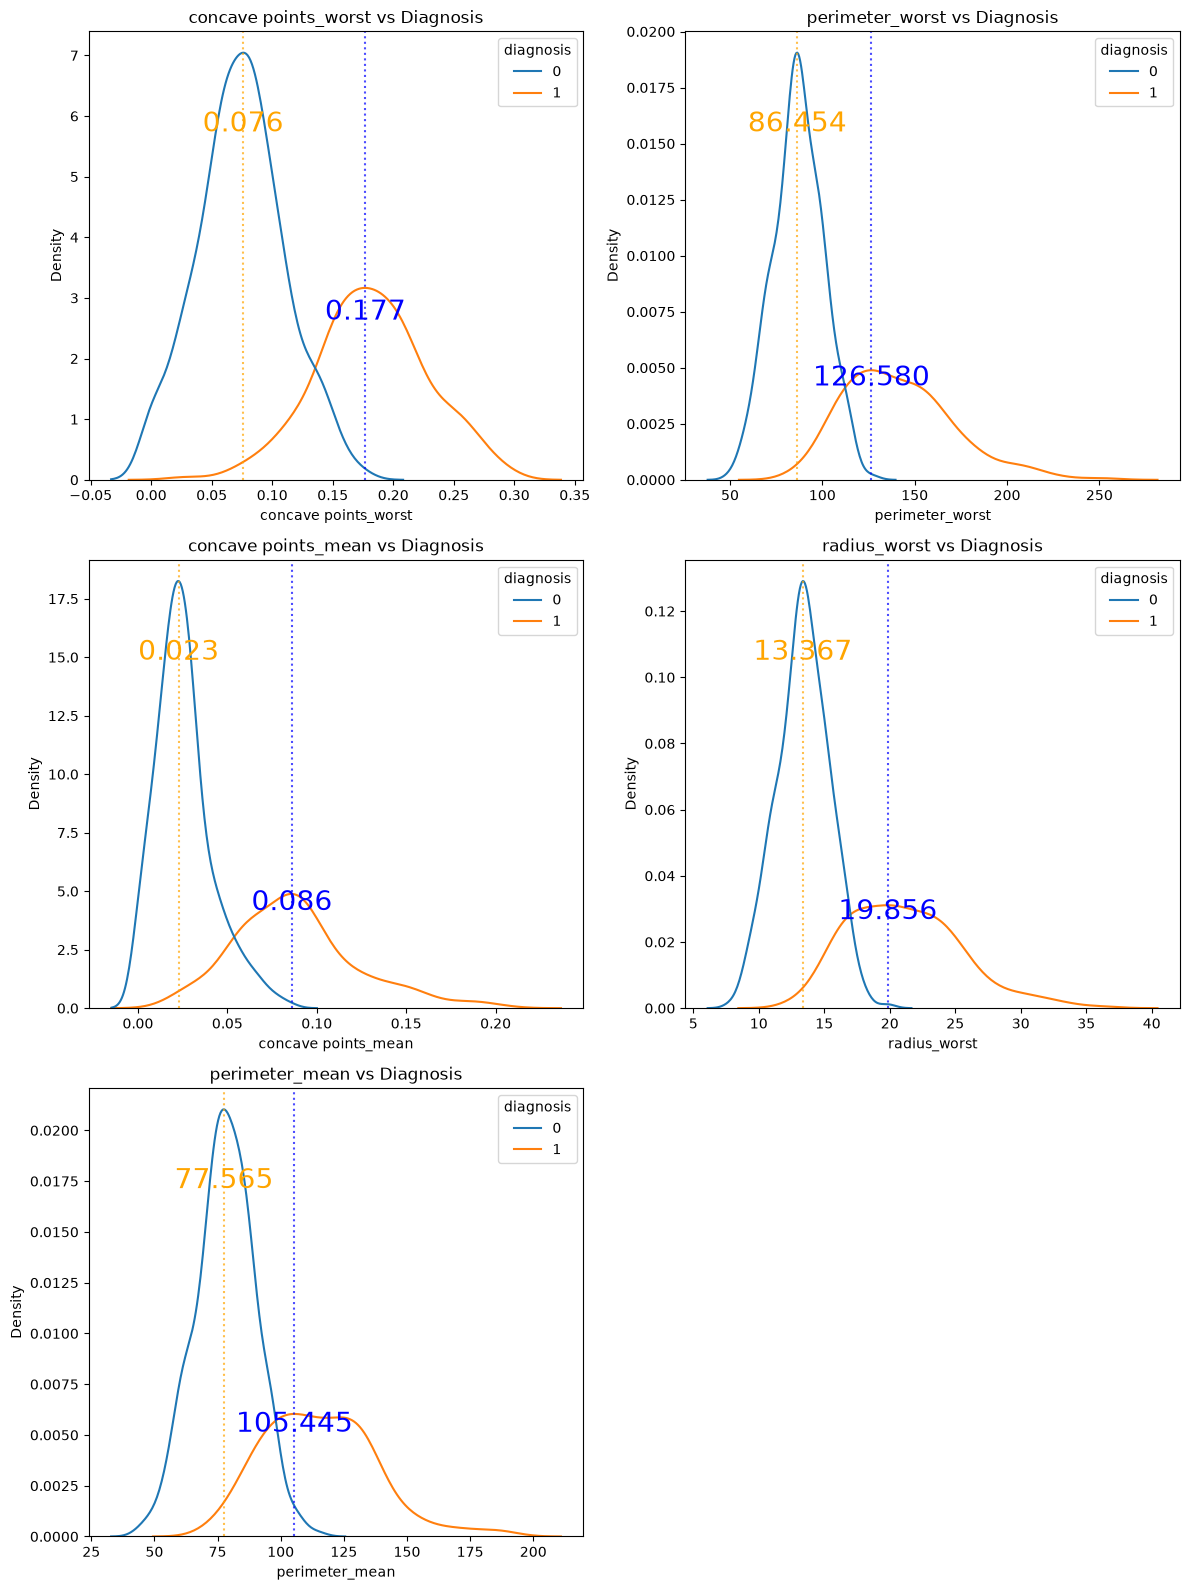

In [105]:
fig , axes = plt.subplots(3,2 , figsize = (12,16))
axes = axes.flatten()
for i,feature in enumerate(Top_features_names):
    sns.kdeplot(data = Top_features_Df , x = feature , hue = 'diagnosis' , ax = axes[i])
    axes[i].set_title(f'{feature} vs Diagnosis', fontsize=12)
    lines = axes[i].get_lines()
    colors = ['blue' , 'orange']
    for line , color in zip(lines,colors):
        x_data = line.get_xdata()
        y_data = line.get_ydata()
        
        if len(y_data) > 0:
            max_idx = np.argmax(y_data)
            peak_x = x_data[max_idx]
            peak_y = y_data[max_idx]
            
            axes[i].axvline(x=peak_x, color=color, linestyle=':', alpha=0.7)
            axes[i].text(peak_x,peak_y*0.8,f'{peak_x:.3f}',color=color,fontsize=20,ha='center',va='bottom',)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()
    

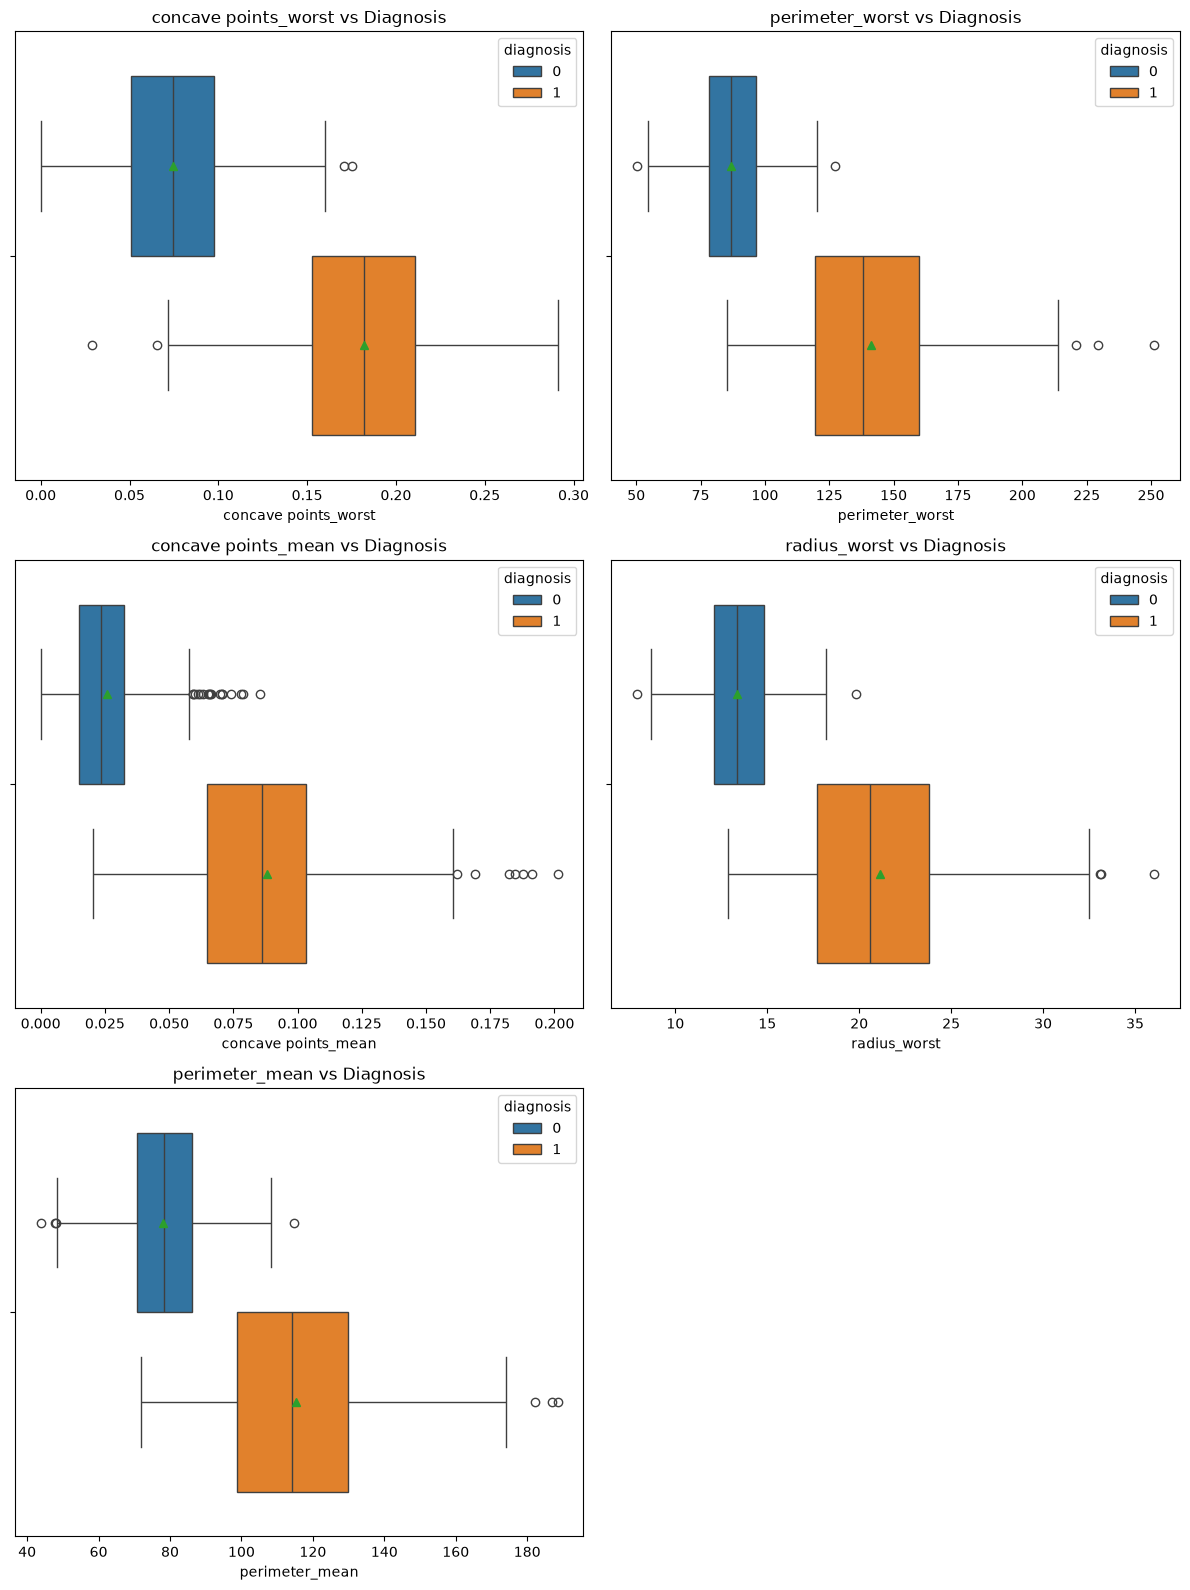

In [80]:
fig , axes = plt.subplots(3,2 , figsize = (12,16))
axes = axes.flatten()
for i,feature in enumerate(Top_features_names):
    sns.boxplot(data = Top_features_Df , x = feature , hue = 'diagnosis' , ax = axes[i] , showmeans = True)
    axes[i].set_title(f'{feature} vs Diagnosis', fontsize=12)


fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

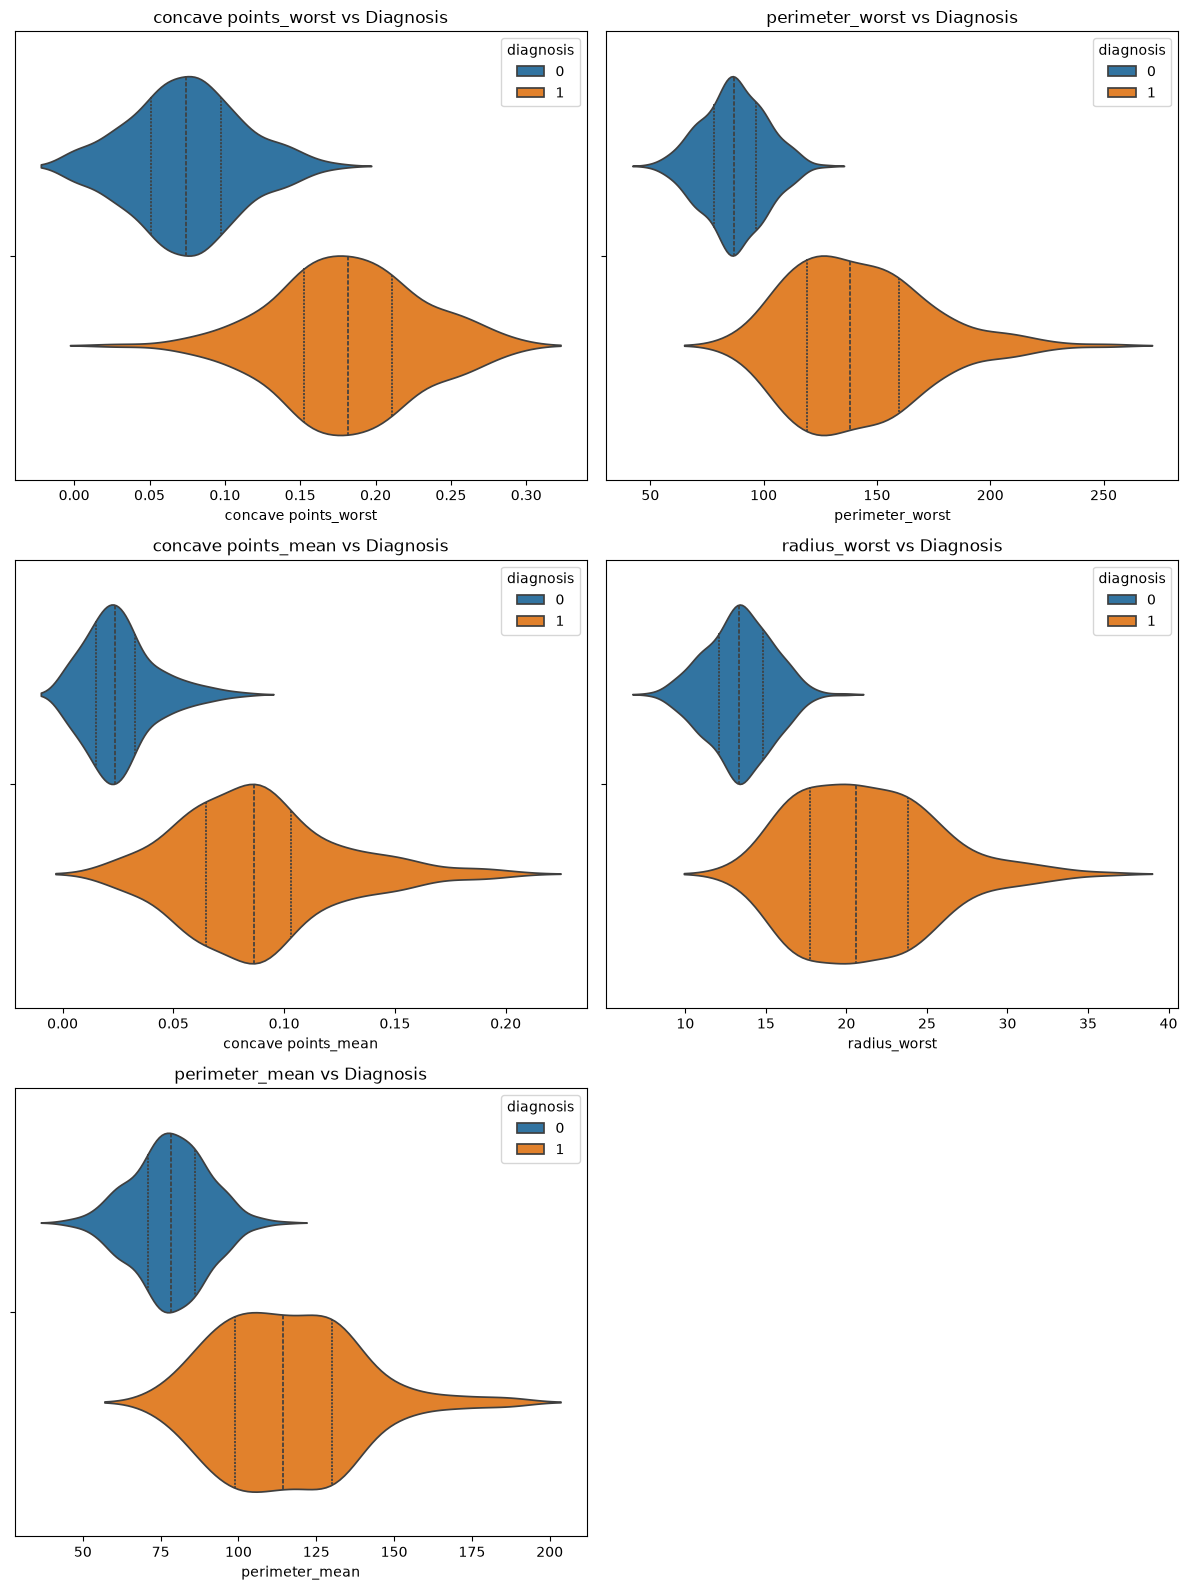

In [88]:
fig , axes = plt.subplots(3,2 , figsize = (12,16))
axes = axes.flatten()
for i,feature in enumerate(Top_features_names):
    sns.violinplot(data = Top_features_Df , x = feature , hue = 'diagnosis' , ax = axes[i] , inner = 'quartile')
    axes[i].set_title(f'{feature} vs Diagnosis', fontsize=12)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

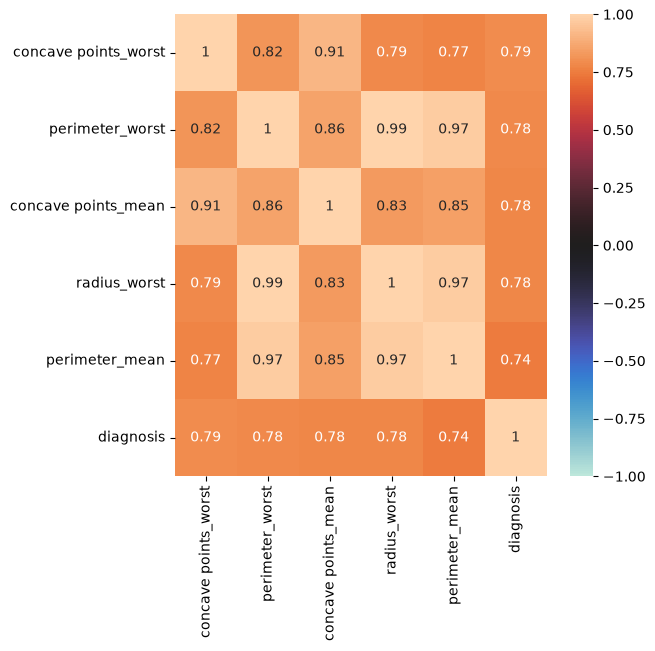

In [104]:
fig , axes = plt.subplots(figsize = (6,6))
sns.heatmap(data = Top_features_Df.corr() , vmin = -1 , vmax = 1 , center = 0,annot = True)

plt.show()

In [98]:
print("From the previous heatmap notice that the relation between concave points worst and the diagnosis is very strong")

From the previous heatmap notice that the relation between concave points worst and the diagnosis is very strong


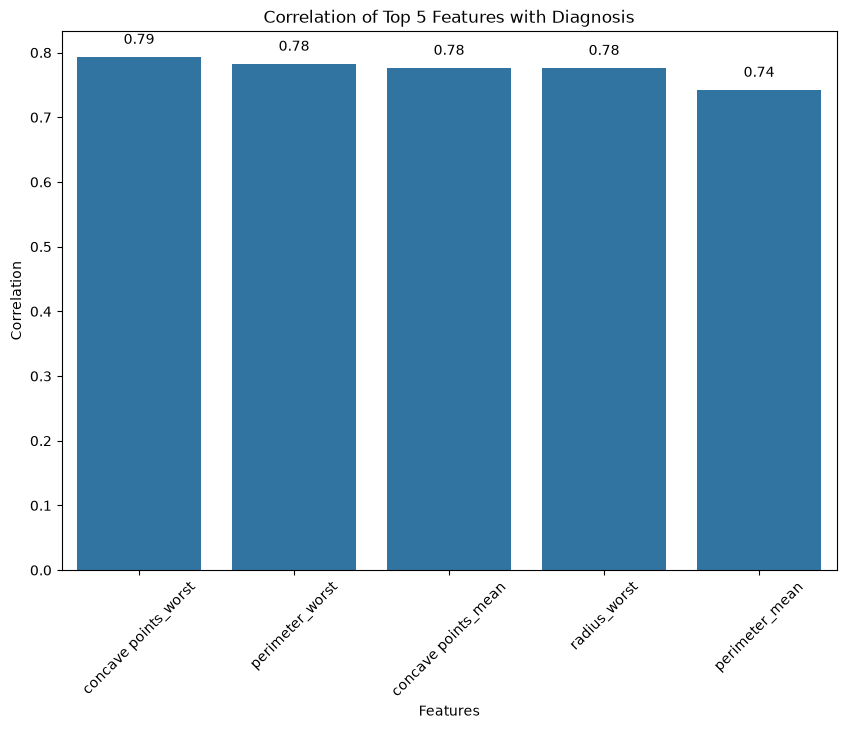

In [103]:
corr = Top_features_Df[Top_features_names + ['diagnosis']].corr()['diagnosis']
corr = corr.drop('diagnosis').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=corr.index, y=corr.values)
for i, value in enumerate(corr.values):
    plt.text(i,value + 0.02,f'{value:.2f}',ha='center')
    
plt.title('Correlation of Top 5 Features with Diagnosis')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.show()

In [119]:
# Here I get the first column to compare it with the another columns in the Top_Features 
Feature_1 = pd.DataFrame(Top_features_Df[Top_features_Df.columns[0]])

Feature_1

,concave points_worst
0,0.2654
1,0.1860
2,0.2430
3,0.2575
4,0.1625
...,...
564,0.2216
565,0.1628
566,0.1418
567,0.2650


In [126]:
# Here I Will drop the first column and copy it in new DataFrame .
Remain_Features = Top_features_Df.drop(columns=[Top_features_Df.columns[0]]).copy()

Remain_Features

,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,diagnosis
0,184.60,0.14710,25.380,122.80,1
1,158.80,0.07017,24.990,132.90,1
2,152.50,0.12790,23.570,130.00,1
3,98.87,0.10520,14.910,77.58,1
4,152.20,0.10430,22.540,135.10,1
...,...,...,...,...,...
564,166.10,0.13890,25.450,142.00,1
565,155.00,0.09791,23.690,131.20,1
566,126.70,0.05302,18.980,108.30,1
567,184.60,0.15200,25.740,140.10,1


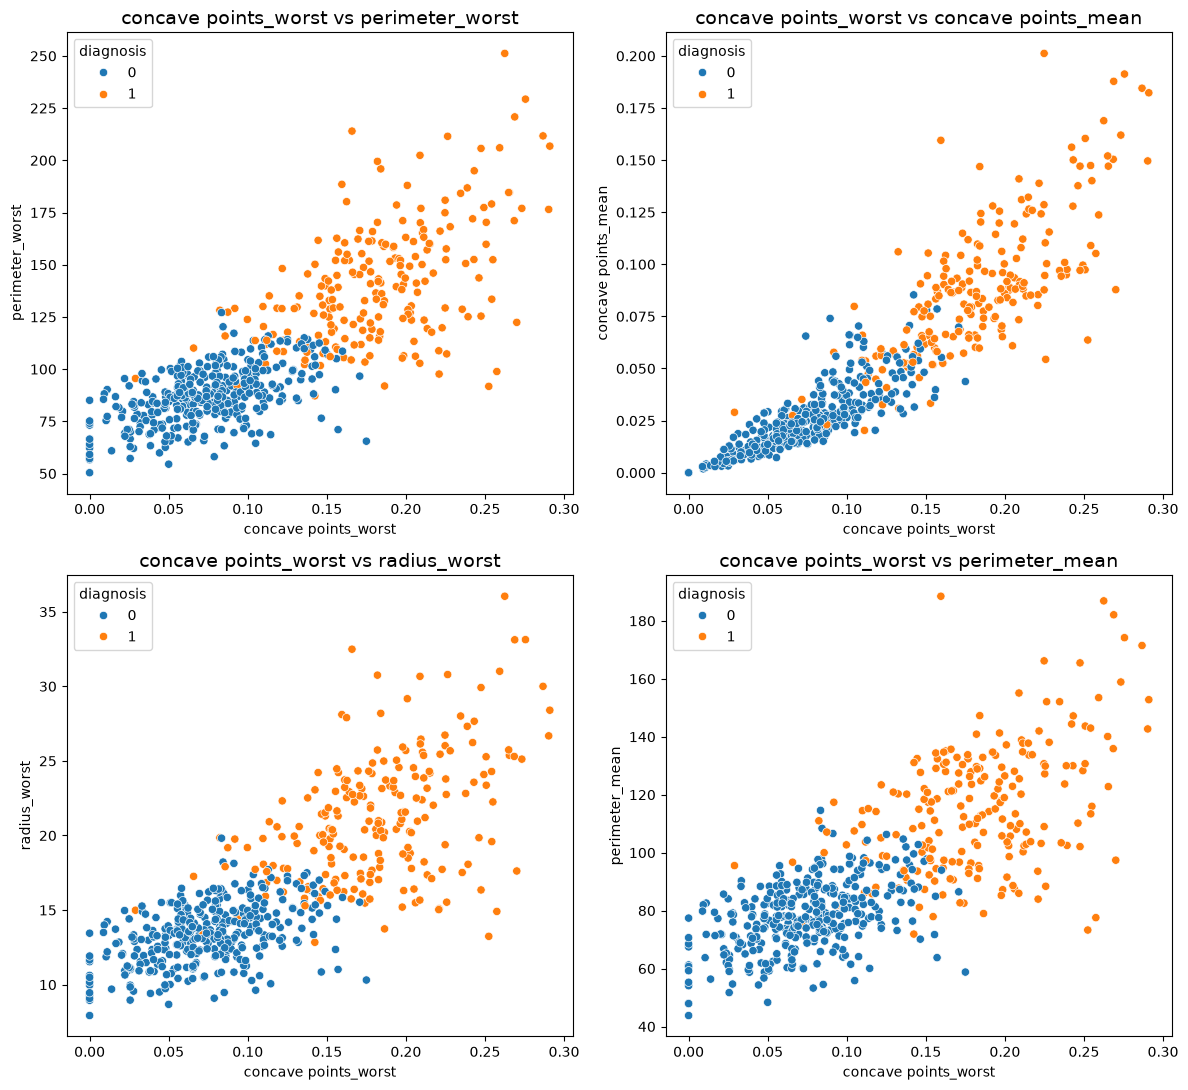

In [ ]:
# Now I will display the factor between the first feature the the remain features 

fig , axes = plt.subplots(3,2 , figsize = (12,16))
axes = axes.flatten()
for i,feature in enumerate(Remain_Features.columns):
    
    sns.scatterplot(data = Top_features_Df,
    x = Feature_1.columns[0],
    y = feature,
    hue = 'diagnosis',
    ax = axes[i])

    axes[i].set_title(f'{Feature_1.columns[0]} vs {feature}', fontsize=14)

for j in range(len(Remain_Features.columns)-1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()